### This is the simple workflow with graph

In [2]:
# show this later on
def function3(input3):
    return input3

In [3]:
def function1(input1):
    return input1 + "from first function"

def function2(input2):
    output=function3("this is function 3 in between")
    return input2 + " " + output + " and savita from second function"

In [5]:
from langgraph.graph import StateGraph
from typing import TypedDict

In [6]:
workflow1=Graph()

NameError: name 'Graph' is not defined

In [65]:
workflow1.add_node("function1", function1)

In [66]:
workflow1.add_node("function2",function2)

In [67]:
workflow1.add_edge("function1","function2")

In [68]:
workflow1.set_entry_point("function1")

In [69]:
workflow1.set_finish_point("function2")

In [70]:
app1=workflow1.compile()

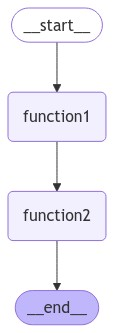

In [71]:
from IPython.display import Image, display

try:
    display(Image(app1.get_graph().draw_mermaid_png()))
except Exception as e:
    # This requires some extra dependencies and is optional
    print(e)

In [72]:
app1.invoke("hi this is sunny ")

'hi this is sunny from first function this is function 3 in between and savita from second function'

In [73]:
input="hi this is sunny "

In [74]:
for output in app1.stream(input):
    for key,value in output.items():
        print(f"here is output from {key}")
        print("_______")
        print(value)
        print("\n")

here is output from function1
_______
hi this is sunny from first function


here is output from function2
_______
hi this is sunny from first function this is function 3 in between and savita from second function




# Now lets create workflow with llm

In [7]:
from langchain_groq import ChatGroq
llm=ChatGroq(model_name="llama-3.1-8b-instant")
llm.invoke("hi").content

d:\Installation_path\ANACONDA\envs\genai\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'How can I assist you today?'

In [8]:
def function1(input):
    llm=ChatGroq(model_name="llama-3.1-8b-instant")
    response=llm.invoke(input).content
    return response
    

In [9]:
def function2(input):
    upper_case=input.upper()
    return upper_case
    

In [11]:
from langgraph.graph import StateGraph

workflow2 = StateGraph(dict)

In [12]:
workflow2.add_node("llm",function1)

In [13]:
workflow2.add_node("upper_string",function2)

In [14]:
workflow2.add_edge("llm","upper_string")

In [15]:
workflow2.set_entry_point("llm")
workflow2.set_finish_point("upper_string")

In [16]:
app2=workflow2.compile()

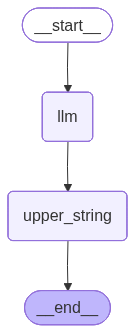

In [17]:
from IPython.display import Image, display

try:
    display(Image(app2.get_graph().draw_mermaid_png()))
except Exception as e:
    # This requires some extra dependencies and is optional
    print(e)

In [18]:
app2.invoke("what is a name of first indian prime minister?")

'THE FIRST INDIAN PRIME MINISTER WAS JAWAHARLAL NEHRU. HE SERVED AS THE PRIME MINISTER OF INDIA FROM AUGUST 15, 1947, TO MAY 27, 1964.'

In [19]:
print(app2.invoke("what is genai explain in detail?"))

GENAI, SHORT FOR GENERAL ARTIFICIAL INTELLIGENCE, REFERS TO A HYPOTHETICAL FORM OF ARTIFICIAL INTELLIGENCE (AI) THAT SURPASSES HUMAN INTELLIGENCE IN A WIDE RANGE OF TASKS ACROSS VARIOUS DOMAINS. IT'S A TYPE OF AI THAT CAN PERFORM ANY INTELLECTUAL TASK THAT A HUMAN CAN, AND POTENTIALLY EVEN THOSE THAT HUMANS CANNOT.

**KEY CHARACTERISTICS OF GENAI:**

1. **AUTONOMOUS LEARNING**: GENAI SYSTEMS CAN LEARN FROM DATA, EXPERIENCE, AND INTERACTIONS WITH THEIR ENVIRONMENT, WITHOUT BEING EXPLICITLY PROGRAMMED FOR EACH SPECIFIC TASK.
2. **GENERAL KNOWLEDGE**: GENAI SYSTEMS POSSESS A BROAD AND DEEP UNDERSTANDING OF THE WORLD, INCLUDING COMMON SENSE, REASONING, AND PROBLEM-SOLVING ABILITIES.
3. **REASONING AND PROBLEM-SOLVING**: GENAI SYSTEMS CAN REASON AND SOLVE COMPLEX PROBLEMS, OFTEN IN A WAY THAT IS EQUIVALENT TO HUMAN REASONING.
4. **SELF-AWARENESS AND CONSCIOUSNESS**: GENAI SYSTEMS MAY BE CAPABLE OF SELF-AWARENESS, CONSCIOUSNESS, AND EVEN EMOTIONS, ALTHOUGH THIS IS STILL A TOPIC OF DEBATE AMO

In [20]:
input="what is a name of first indian prime minister?"

In [21]:
for output in app2.stream(input):
    for key,value in output.items():
        print(f"here is output from {key}")
        print("_______")
        print(value)
        print("\n")

here is output from llm
_______
The first Indian Prime Minister was Jawaharlal Nehru. He served as the Prime Minister of India from August 15, 1947, until his death on May 27, 1964.


here is output from upper_string
_______
THE FIRST INDIAN PRIME MINISTER WAS JAWAHARLAL NEHRU. HE SERVED AS THE PRIME MINISTER OF INDIA FROM AUGUST 15, 1947, UNTIL HIS DEATH ON MAY 27, 1964.




Here lets create our own output token counter

In [49]:
from langchain_groq import ChatGroq

llm = ChatGroq(model_name="llama-3.1-8b-instant")

def function1(state):
    question = state.get("text", "")
    response = llm.invoke(question).content
    return {"text": response}

In [56]:
def function3(state):
    text = state.get("text", "")
    tokens = len(text.split())

    return {
        "text": text,
        "tokens": tokens
    }

In [57]:
from langgraph.graph import StateGraph, START, END

# state structure
class State(dict):
    pass

workflow3 = StateGraph(State)

workflow3.add_node("llm", function1)
workflow3.add_node("token_counter", function3)

workflow3.add_edge(START, "llm")
workflow3.add_edge("llm", "token_counter")
workflow3.add_edge("token_counter", END)

app3 = workflow3.compile()

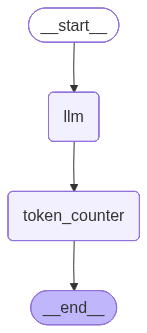

In [52]:
from IPython.display import Image, display

try:
    display(Image(app3.get_graph().draw_mermaid_png()))
except Exception as e:
    # This requires some extra dependencies and is optional
    print(e)

In [54]:
def function3(state):
    print("STATE RECEIVED:", state)
    text = state.get("text", "")
    tokens = len(text.split())
    print("TOKENS:", tokens)
    return {"tokens": tokens}

In [58]:
result=app3.invoke({"text": "what is the name of the first Indian prime minister?"})
print(result)

None


In [43]:
app3.invoke({"text": "what is genai explain in detail?"})

In [59]:
from langchain_community.tools.tavily_search import TavilySearchResults

tool = TavilySearchResults(max_results=2)
tools = [tool]
tool.invoke("What's a 'node' in LangGraph?")

C:\Users\aksha\AppData\Local\Temp\ipykernel_300\3979812345.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool = TavilySearchResults(max_results=2)


[{'title': "A Beginner's Guide to Getting Started with Nodes in LangGraph",
  'url': 'https://medium.com/ai-engineering-bootcamp/a-beginners-guide-to-getting-started-with-nodes-in-langgraph-cdd551e8d79c',
  'content': 'Whether you’re building a simple two-step agent, a multi-branching “choose-your-own-adventure” assistant, or a full-blown workflow that feels like it should have a boarding pass…\n\nNodes are the building blocks that make your agent predictable, traceable, and honestly… sane.\n\nBut here’s the best part: Once you understand what nodes are and how they behave, the rest of your LangGraph journey becomes way clearer.\n\nBy the end of this guide, you’ll be able to:\n\n spot a node in the wild,\n create your own nodes (yes, you),\n chain them together like a pro,\n and build simple flows that actually make sense.\n\n## What Exactly Is a Node in LangGraph?\n\nA node is just a function or an LLM call that transforms your state and moves your graph forward.\n\nLet’s break that d

### Question: Can we integrating a RAG Pipeline?

### Answer: yes we can!

In [116]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings

embeddings = GoogleGenerativeAIEmbeddings(
    model="models/text-embedding-004"
)

In [117]:
from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGroq(model_name="llama-3.1-8b-instant")


In [118]:
llm.invoke("hi").content

'How can I assist you today?'

In [119]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_community.document_loaders import TextLoader, DirectoryLoader
from langchain_community.vectorstores import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [123]:
loader = DirectoryLoader("data", glob="*.txt", loader_cls=TextLoader)
docs=loader.load()
text_splitter=RecursiveCharacterTextSplitter(
    chunk_size=100,
    chunk_overlap=50
)
new_docs = text_splitter.split_documents(documents=docs)
doc_strings = [doc.page_content for doc in new_docs]

In [121]:
db = Chroma.from_documents(new_docs, embeddings)

retriever = db.as_retriever(search_kwargs={"k": 3})

GoogleGenerativeAIError: Error embedding content (INVALID_ARGUMENT): 400 INVALID_ARGUMENT. {'error': {'code': 400, 'message': 'API key not valid. Please pass a valid API key.', 'status': 'INVALID_ARGUMENT', 'details': [{'@type': 'type.googleapis.com/google.rpc.ErrorInfo', 'reason': 'API_KEY_INVALID', 'domain': 'googleapis.com', 'metadata': {'service': 'generativelanguage.googleapis.com'}}, {'@type': 'type.googleapis.com/google.rpc.LocalizedMessage', 'locale': 'en-US', 'message': 'API key not valid. Please pass a valid API key.'}]}}

In [7]:
query = "what is meta llama3?"
docs = retriever.get_relevant_documents(query)
print(docs[0].metadata)
print(docs[0].page_content)

for doc in docs:
    print(doc)

C:\Users\sunny\AppData\Local\Temp\ipykernel_63316\1985905.py:2: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  docs = retriever.get_relevant_documents(query)


{'source': '..\\data\\llama3.txt'}
Alongside the release of Llama 3, Meta added virtual assistant features to Facebook and WhatsApp in
page_content='Alongside the release of Llama 3, Meta added virtual assistant features to Facebook and WhatsApp in' metadata={'source': '..\\data\\llama3.txt'}
page_content='by Meta AI starting in February 2023.[2][3] The latest version is Llama 3 released in April' metadata={'source': '..\\data\\llama3.txt'}
page_content='Llama 2, Meta AI started releasing instruction fine-tuned versions alongside foundation models.[7]' metadata={'source': '..\\data\\llama3.txt'}


In [95]:
def function_1(AgentState):

    messages = AgentState.get("messages", [])

    question = messages[-1]

    complete_prompt = (
        "Your task is to provide only the brief answer based on the user query. "
        "Don't include too much reasoning. Following is the user query: "
        + question
    )

    response = llm.invoke(complete_prompt)

    messages.append(response.content)

    return {"messages": messages}

In [96]:
AgentState={}

In [97]:
AgentState["messages"]=[]

In [98]:
AgentState

{'messages': []}

In [99]:
AgentState["messages"].append("hi, how are you?")

In [100]:
AgentState

{'messages': ['hi, how are you?']}

In [101]:
AgentState["messages"].append("hi, what you doing?")

In [102]:
AgentState

{'messages': ['hi, how are you?', 'hi, what you doing?']}

In [108]:
def function_2(AgentState):

    messages = AgentState.get("messages", [])

    question = messages[-1]

    template = """Answer the question based only on the following context:
    {context}

    Question: {question}
    """

    prompt = ChatPromptTemplate.from_template(template)

    retrieval_chain = (
        {"context": retriever, "question": RunnablePassthrough()}
        | prompt
        | llm
        | StrOutputParser()
    )

    result = retrieval_chain.invoke(question)

    messages.append(result)

    return {"messages": messages}

In [111]:
from langgraph.graph import StateGraph, START, END

workflow4 = StateGraph(dict)

workflow4.add_node("RAGtool", function_2)
workflow4.add_node("LLM", function_1)

workflow4.add_edge(START, "RAGtool")
workflow4.add_edge("RAGtool", "LLM")
workflow4.add_edge("LLM", END)

app4 = workflow4.compile()

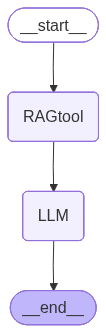

In [112]:
from IPython.display import Image, display

try:
    display(Image(app4.get_graph().draw_mermaid_png()))
except Exception as e:
    # This requires some extra dependencies and is optional
    print(e)

In [113]:
inputs = {"messages": ["Tell me about llama3 model"]}

In [114]:
for output in app4.stream(inputs):
    # stream() yields dictionaries with output keyed by node name
    for key, value in output.items():
        print(f"Output from node '{key}':")
        print("---")
        print(value)
    print("\n---\n")

NameError: name 'retriever' is not defined

In [18]:
loader2=DirectoryLoader("../data2",glob="./*.txt",loader_cls=TextLoader)
docs2=loader2.load()

text_splitter=RecursiveCharacterTextSplitter(
    chunk_size=100,
    chunk_overlap=50
)
new_docs2 = text_splitter.split_documents(documents=docs2)
doc_strings2 = [doc.page_content for doc in new_docs2]

In [19]:

db2 = Chroma.from_documents(new_docs2, embeddings)
retriever2 = db2.as_retriever(search_kwargs={"k": 3})

In [20]:
query = "Tell me about India's Industrial Growth?"
docs = retriever2.get_relevant_documents(query)
print(docs[0].metadata)
print(docs[0].page_content)

for doc in docs:
    print(doc)

{'source': '..\\data2\\indian_economy.txt'}
India’s industrial growth has outpaced expectations, raising hopes that the economy will avoid a
page_content='India’s industrial growth has outpaced expectations, raising hopes that the economy will avoid a' metadata={'source': '..\\data2\\indian_economy.txt'}
page_content='India’s strong export sectors—including textiles, IT services, and automotive manufacturing—had' metadata={'source': '..\\data2\\indian_economy.txt'}
page_content='India’s last eight years of GDP (hypothetical data):' metadata={'source': '..\\data2\\indian_economy.txt'}


1. TypedDict:
- TypedDict is a special type that allows you to define a dictionary in Python where each key has a specific type.
It’s useful when you want to enforce type checks on the keys and values of a dictionary.

2. Annotated:
- Annotated is used to add metadata or constraints to a type.
It’s typically used for adding additional information, like constraints or descriptions, to the type.

3. Sequence[BaseMessage]:
- Sequence is a generic type from Python's typing module that represents a list-like structure (such as a list or tuple) where the order matters, and you can access elements by their position.

4. BaseMessage:
- Basemessage: This assumes you're working with the LangChain framework, and BaseMessage is part of its core messaging system. It is typically used when handling or processing messages in LangChain's workflows

5. operator.add:

- operator.add is a function from Python’s operator module that performs addition (+) on its arguments.
In this context, operator.add is being used as metadata for the Annotated type, likely suggesting that the sequence of BaseMessage objects is meant to be "added" or concatenated with another sequence at some point. It’s an indicator of how the messages field will be treated in the logic of your program.


- **TopicSelectionParser:** A Pydantic model that defines two fields (Topic and Reasoning), both of which are required to be strings.
- **Field:** Adds metadata, like descriptions, and can also be used for validation and constraints.
- **Pydantic’s Role:** Ensures that the data matches the expected structure and types, raising validation errors if the data is invalid.

### Putting It All Together:

- The line messages: Annotated[Sequence[BaseMessage], operator.add] defines a field messages that:

- Must be a sequence (like a list or tuple) of BaseMessage objects.
Has the additional annotation operator.add, which suggests that this sequence is intended to support addition (i.e., concatenation of multiple sequences of messages).

messages: Annotated[Sequence[BaseMessage], operator.add]

"messages": [BaseMessage("Hello!", "Alice"), BaseMessage("Hi!", "Bob")]

In [22]:
from typing import TypedDict, Annotated, Sequence
import operator
from langchain_core.messages import BaseMessage
from langchain.prompts import PromptTemplate

In [23]:
class AgentState(TypedDict):
    # The 'messages' field should be a sequence of strings, and we annotate it with 'operator.add'
    # This implies we might want to "add" new messages to the sequence later
    messages: Annotated[Sequence[BaseMessage], operator.add]

In [24]:
from pydantic import BaseModel , Field
class TopicSelectionParser(BaseModel):
    Topic: str = Field(description='Selected Topic')
    Reasoning: str = Field(description='Reasoning behind topic selection')

In [25]:
from langchain.output_parsers import PydanticOutputParser
parser = PydanticOutputParser(pydantic_object=TopicSelectionParser)

In [27]:
print(parser.get_format_instructions())

The output should be formatted as a JSON instance that conforms to the JSON schema below.

As an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}
the object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is not well-formatted.

Here is the output schema:
```
{"properties": {"Topic": {"description": "Selected Topic", "title": "Topic", "type": "string"}, "Reasoning": {"description": "Reasoning behind topic selection", "title": "Reasoning", "type": "string"}}, "required": ["Topic", "Reasoning"]}
```


In [29]:
def function_1(state):
    message=state["messages"]
    question=message[-1]
    print(question)
    
    template="""
    Your task is to classify the given user query into one of the following categories: [India, Not Related]. 
    Only respond with the category name and nothing else.

    User query: {question}
    {format_instructions}
    """
    
    prompt = PromptTemplate(template=template,
                                    input_variables=[question],
                                    partial_variables={
                                        "format_instructions" : parser.get_format_instructions()                                    }
                                    )
    chain =  prompt | llm | parser
    
    response = chain.invoke({"question":question,"format_instructions" : parser.get_format_instructions() })

    print(response)

    return {"messages": [response.Topic]}

In [ ]:
template="""
    Your task is to classify the given user query into one of the following categories: [India, Not Related]. 
    Only respond with the category name and nothing else.

    User query: "Tell me about India's Industrial Growth"
    The output should be formatted as a JSON instance that conforms to the JSON schema below.

    As an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}
    the object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is not well-formatted.

    Here is the output schema:
    ```
    {"properties": {"Topic": {"description": "Selected Topic", "title": "Topic", "type": "string"}, "Reasoning": {"description": "Reasoning behind topic selection", "title": "Reasoning", "type": "string"}}, "required": ["Topic", "Reasoning"]}
        """

In [31]:
state={"messages": ["Tell me about India's Industrial Growth"]}

In [32]:
function_1(state)

Tell me about India's Industrial Growth
Topic='India' Reasoning="The user query is about India's Industrial Growth, which is related to India."


{'messages': ['India']}

In [35]:
def function_2(state):
    print('-> Calling RAG ->')
    messages = state['messages']
    question = messages[0] ## Fetching the user question
    print(question)

    template = """Answer the question based only on the following context:
    {context}

    Question: {question}
    """
    prompt = ChatPromptTemplate.from_template(template)
    
    print(prompt)

    retrieval_chain = (
        {"context": retriever, "question": RunnablePassthrough()}
        | prompt
        | llm
        | StrOutputParser()
        )
    result = retrieval_chain.invoke(question)
    return  {"messages": [result]}

In [36]:
function_2({'messages': ['India']})

-> Calling RAG ->
India
input_variables=['context', 'question'] input_types={} partial_variables={} messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template='Answer the question based only on the following context:\n    {context}\n\n    Question: {question}\n    '), additional_kwargs={})]


{'messages': ['Yes, the context mentions India.']}

In [ ]:
def function_3(state):
    print('-> Calling LLM ->')

    messages = state['messages']
    question = messages[0] ## Fetching the user question

    # Normal LLM call
    complete_query = "Anwer the follow question with your knowledge of the real world. Following is the user question: " + question
    response = llm.invoke(complete_query)
    return {"messages": [response.content]}

In [37]:
def router(state):
    print('-> Router ->')
    
    messages = state["messages"]
    last_message = messages[-1]
    print(last_message)
    if 'India' in last_message:
        return 'RAG Call'
    else:
        return 'LLM Call'

In [ ]:
from langgraph.graph import StateGraph,END

workflow5 = StateGraph(AgentState) ### StateGraph with AgentState
workflow5.add_node("agent", function_1)
workflow5.add_node("RAG", function_2)
workflow5.add_node("LLM", function_3)
workflow5.set_entry_point("agent")

workflow5.add_conditional_edges(
    "agent",
    router,
    {
        "RAG Call": "RAG",
        "LLM Call": "LLM",
    }
)

workflow5.add_edge("RAG",END)
workflow5.add_edge("LLM",END)
app5=workflow5.compile()

In [ ]:
from IPython.display import Image, display

try:
    display(Image(app5.get_graph().draw_mermaid_png()))
except Exception as e:
    # This requires some extra dependencies and is optional
    print(e)

In [ ]:
inputs = {"messages": ["Tell me about India's Industrial Growth"]}

In [ ]:
output = app5.invoke(inputs)

In [ ]:
output

In [ ]:
inputs = {"messages": ["Tell me about first prime minister of india?"]}

In [ ]:
output = app5.invoke(inputs)

In [ ]:
output